In [4]:
import sys
sys.path.append("..")
import re
import pandas as pd
import matplotlib.pyplot as plt
from src.data import load_cuad

contracts = load_cuad()

count       510.000000
mean      52563.005882
std       55946.484865
min         645.000000
25%       16416.250000
50%       33143.000000
75%       66394.750000
max      338211.000000
dtype: float64


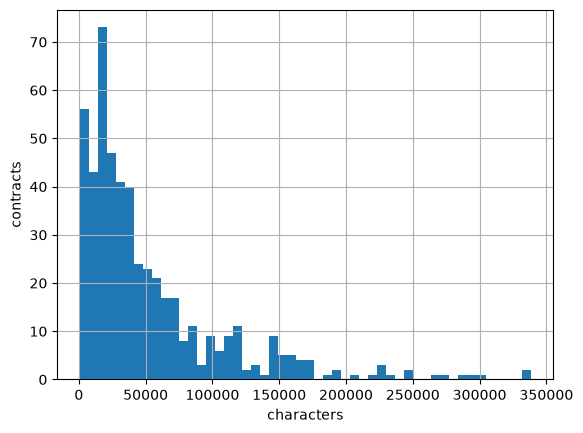

In [5]:
lengths = pd.Series([len(c["text"]) for c in contracts])
print(lengths.describe())
lengths.hist(bins=50)
plt.xlabel("characters")
plt.ylabel("contracts")
plt.show()

In [6]:
rows = []
for c in contracts:
    for clause, spans in c["gold"].items():
        for s, e in spans:
            rows.append({"clause": clause, "length": e - s, "rel_pos": s / len(c["text"])})
spans_df = pd.DataFrame(rows)

print(spans_df.groupby("clause").length.describe().round(0))
print(spans_df.groupby("clause").rel_pos.mean().round(2))

                                    count   mean    std   min    25%    50%  \
clause                                                                        
Cap On Liability                    672.0  377.0  255.0  33.0  201.0  306.0   
Governing Law                       464.0  206.0  111.0   6.0  132.0  178.0   
Non-Compete                         259.0  392.0  331.0   9.0  204.0  309.0   
Notice Period To Terminate Renewal  122.0  307.0  137.0  13.0  212.0  298.0   
Renewal Term                        210.0  317.0  294.0  13.0  189.0  270.0   
Termination For Convenience         246.0  222.0  202.0  34.0  112.0  163.0   
Uncapped Liability                  167.0  452.0  248.0  33.0  264.0  423.0   

                                      75%     max  
clause                                             
Cap On Liability                    484.0  1887.0  
Governing Law                       250.0   856.0  
Non-Compete                         476.0  2780.0  
Notice Period To Terminate R

In [7]:
counts = []
for c in contracts:
    for clause, spans in c["gold"].items():
        counts.append({"clause": clause, "n_spans": len(spans)})
counts_df = pd.DataFrame(counts)
print(counts_df[counts_df.n_spans > 0].groupby("clause").n_spans.describe().round(1))

                                    count  mean  std  min  25%  50%  75%   max
clause                                                                        
Cap On Liability                    275.0   2.4  2.0  1.0  1.0  2.0  3.0  16.0
Governing Law                       437.0   1.1  0.3  1.0  1.0  1.0  1.0   4.0
Non-Compete                         119.0   2.2  2.0  1.0  1.0  2.0  2.5  12.0
Notice Period To Terminate Renewal  111.0   1.1  0.3  1.0  1.0  1.0  1.0   3.0
Renewal Term                        176.0   1.2  0.6  1.0  1.0  1.0  1.0   5.0
Termination For Convenience         183.0   1.3  0.6  1.0  1.0  1.0  2.0   4.0
Uncapped Liability                  111.0   1.5  0.9  1.0  1.0  1.0  2.0   5.0


In [8]:
heading = re.compile(r"^\s*\d+(\.\d+)*\.?\s+[A-Z]", re.M)
n_headings = pd.Series([len(heading.findall(c["text"])) for c in contracts])
print(n_headings.describe())
print("contracts with 5+ numbered headings:", (n_headings >= 5).mean().round(2))

count    510.000000
mean      36.503922
std       60.951581
min        0.000000
25%        3.000000
50%       14.000000
75%       47.000000
max      753.000000
dtype: float64
contracts with 5+ numbered headings: 0.7


In [9]:
from src.chunking import fixed_chunks, overlaps

rows = []
for c in contracts[:100]:
    chunks = fixed_chunks(c["text"])
    for clause, spans in c["gold"].items():
        if spans:
            pos = sum(overlaps(ch, spans) for ch in chunks)
            rows.append({"clause": clause, "pos_chunks": pos, "total": len(chunks)})
base = pd.DataFrame(rows)
base["pct_positive"] = base.pos_chunks / base.total * 100
print(base.groupby("clause").pct_positive.mean().round(1))

clause
Cap On Liability                      5.6
Governing Law                         4.8
Non-Compete                           6.7
Notice Period To Terminate Renewal    4.7
Renewal Term                          4.3
Termination For Convenience           4.9
Uncapped Liability                    3.2
Name: pct_positive, dtype: float64
